In [1]:
import os
import sys
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


sys.path.append(os.path.abspath('..')) 


from src.processing.nlp_extractors import ScholarshipDataProcessor


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


tqdm.pandas(desc="Processing NLP Pipeline")

In [2]:
print(">>> Loading Raw Data...")
all_data = []
# تأكد من وضع مسار مجلد البيانات الصحيح
folder_path = '../data_Json' # عدل المسار إذا لزم الأمر

file_paths = glob.glob(os.path.join(folder_path, '*_scholarships_data*.json'))
for file_path in file_paths:
    try:
        df_temp = pd.read_json(file_path)
        df_temp['source_file'] = os.path.basename(file_path)
        all_data.append(df_temp)
    except Exception as e:
        print(f"Error loading {os.path.basename(file_path)}: {e}")

df_raw = pd.concat(all_data, ignore_index=True)
print(f" Total records loaded: {len(df_raw)}")
df_raw.head(2)

>>> Loading Raw Data...
 Total records loaded: 2526


,scholarship_name,country,degree_level,funding_type,awards_available,deadline,tags,description,scholarship_details,eligibility,application_process,application_link,source_file
0,International Titanium Association Scholarship...,USA,Computer Science,"$4,000",3,"May 14, 2026","[GPA, Selected Major(s), Current Year in Schoo...","The International Titanium Association, a non-...",N/A,N/A,N/A,https://www.scholarships.com/scholarships/inte...,computer_science_scholarships_data.json
1,Eye-Bank for Sight Restoration STEM Scholarship,USA,Computer Science,"$3,000",1,"May 15, 2026","[State Selection, Selected Major(s), Current Y...",The Eye-Bank together with the Fabian family c...,"$3,000 scholarship awarded annually\nOpen to u...",Must reside in The Eye-Bank’s service area: Ne...,Visit www.eyedonation.org/scholarship/stem to ...,https://www.scholarships.com/scholarships/eye-...,computer_science_scholarships_data.json


In [3]:
print(">>> Initializing the NLP Processor (This might take a moment to load spaCy)...")
processor = ScholarshipDataProcessor(use_zero_shot=False) # اجعلها True إذا كان جهازك يتحمل

print(">>> Extracting Funding Data...")
df_raw[['funding_category', 'funding_amount']] = df_raw.progress_apply(processor.process_funding, axis=1)

print(">>> Extracting Degree Levels & Majors...")
df_raw[['academic_major', 'academic_level']] = df_raw.progress_apply(processor.process_degree_level, axis=1)

print("Processing Complete!")

INFO: Initializing NLP Models...


>>> Initializing the NLP Processor (This might take a moment to load spaCy)...
>>> Extracting Funding Data...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

>>> Extracting Degree Levels & Majors...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

Processing Complete!


In [4]:
total_rows = len(df_raw)

# حساب القيم المجهولة
unspecified_level = (df_raw['academic_level'] == 'Unspecified').sum()
unspecified_funding = (df_raw['funding_category'] == 'Variable / Unspecified').sum()

print("--- Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Academic Level Extraction Failure: {unspecified_level} records ({(unspecified_level/total_rows)*100:.1f}%)")
print(f"Funding Category Extraction Failure: {unspecified_funding} records ({(unspecified_funding/total_rows)*100:.1f}%)")


if unspecified_level > 0:
    print("\n--- Sample of Failed Academic Levels (Needs Regex tuning) ---")
    display(df_raw[df_raw['academic_level'] == 'Unspecified'][['scholarship_name', 'description']].head())

--- Extraction Quality Report ---
Total Processed: 2526
Academic Level Extraction Failure: 329 records (13.0%)
Funding Category Extraction Failure: 166 records (6.6%)

--- Sample of Failed Academic Levels (Needs Regex tuning) ---


,scholarship_name,description
0,International Titanium Association Scholarship...,"The International Titanium Association, a non-..."
5,Reason One Mentorship and Scholarship Program,The Reason One Mentorship & Scholarship Progra...
7,Betty Stevens-Frecknall Scholarship,The Betty Stevens-Frecknall Scholarship is a p...
10,Project STEM Heroes Scholarship,"""You are the solution."" Inspired by the movie ..."
12,SBB Research Group STEM Scholarship,The SBB Research Group STEM Scholarship encour...


C:\Users\shaza\AppData\Local\Temp\ipykernel_16564\2505976595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
C:\Users\shaza\AppData\Local\Temp\ipykernel_16564\2505976595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
C:\Users\shaza\AppData\Local\Temp\ipykernel_16564\2505976595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False

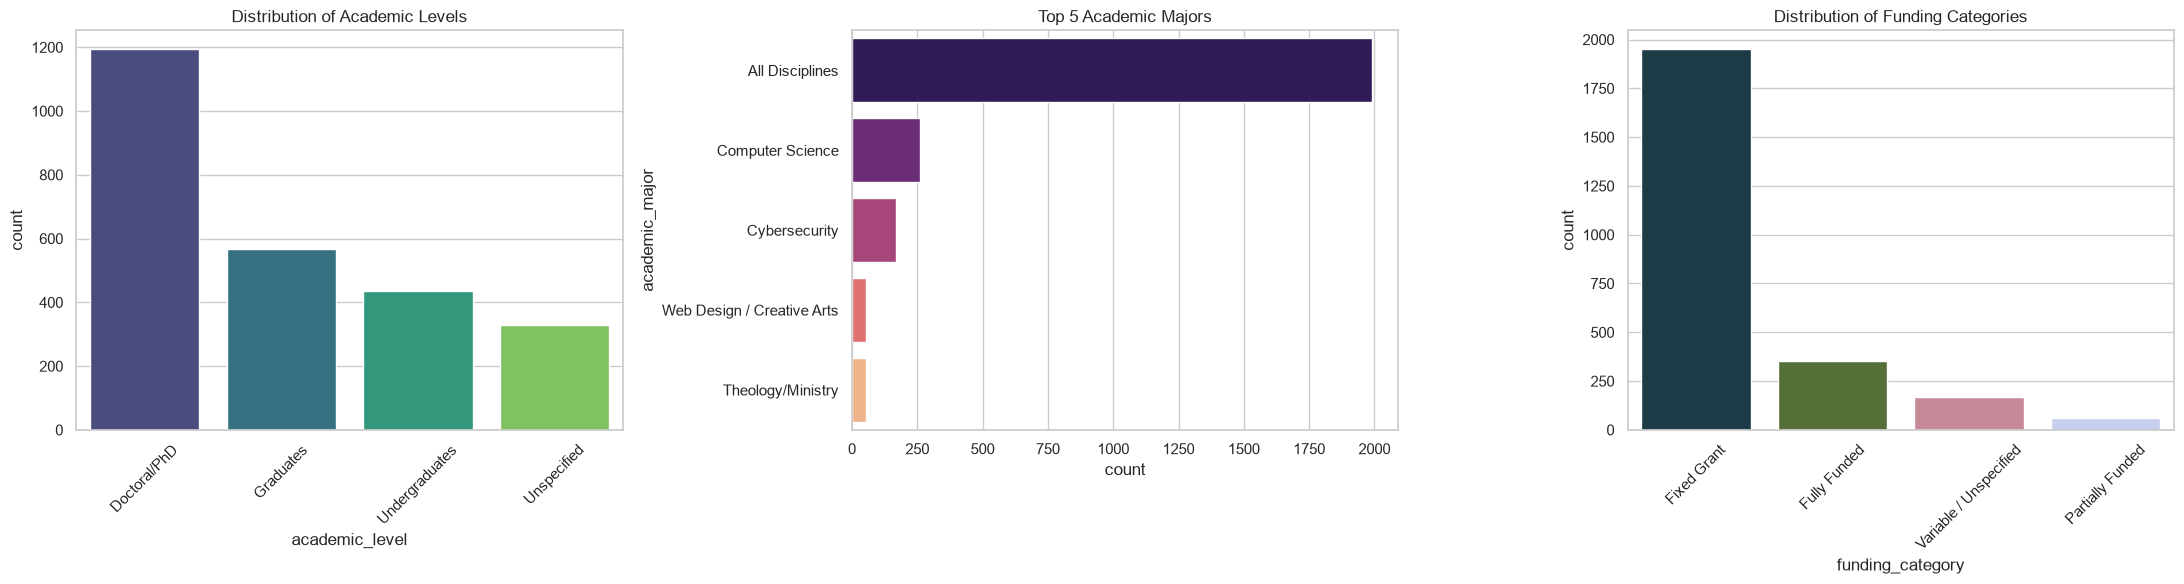

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. توزيع المراحل الأكاديمية
sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
axes[0].set_title('Distribution of Academic Levels')
axes[0].tick_params(axis='x', rotation=45)

# 2. توزيع التخصصات (نأخذ أعلى 5 فقط)
top_majors = df_raw['academic_major'].value_counts().nlargest(5).index
sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
axes[1].set_title('Top 5 Academic Majors')

# 3. توزيع فئات التمويل
sns.countplot(data=df_raw, x='funding_category', ax=axes[2], palette="cubehelix", order=df_raw['funding_category'].value_counts().index)
axes[2].set_title('Distribution of Funding Categories')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
print("--- 1. Academic Level Distribution ---")
# حساب العدد والنسبة المئوية لكل مرحلة دراسية تم استخراجها
level_dist = df_raw['academic_level'].value_counts()
level_pct = df_raw['academic_level'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': level_dist, 'Percentage %': level_pct.round(2)})
display(dist_df)

print("\n--- 2. Funding Category Distribution ---")
# حساب العدد والنسبة لعمود التمويل
funding_dist = df_raw['funding_category'].value_counts()
funding_pct = df_raw['funding_category'].value_counts(normalize=True) * 100
dist_funding_df = pd.DataFrame({'Count': funding_dist, 'Percentage %': funding_pct.round(2)})
display(dist_funding_df)

--- 1. Academic Level Distribution ---


,Count,Percentage %
academic_level,,
Doctoral/PhD,1193,47.23
Graduates,568,22.49
Undergraduates,436,17.26
Unspecified,329,13.02



--- 2. Funding Category Distribution ---


,Count,Percentage %
funding_category,,
Fixed Grant,1949,77.16
Fully Funded,351,13.90
Variable / Unspecified,166,6.57
Partially Funded,60,2.38


In [7]:
print("--- QA: Academic Level Extraction Verification ---")
# 1. تحديد السجلات الصحيحة وأخذ نسخة آمنة
valid_levels = df_raw[df_raw['academic_level'] != 'Unspecified'].copy()

# 2. أخذ العينات بطريقة الخلط (Shuffle) ثم سحب أول 20 من كل مجموعة (Head)
# هذه الطريقة تتجنب استخدام apply التي تسبب مشاكل الفهرس
sample_levels = valid_levels.sample(frac=1, random_state=42).groupby('academic_level').head(10)

# 3. العرض
display(sample_levels[['scholarship_name', 'description', 'academic_level', 'academic_major']])

print("\n--- QA: Funding Extraction Verification ---")
# 1. تحديد السجلات الصحيحة للتمويل وأخذ نسخة آمنة
valid_funding = df_raw[df_raw['funding_category'] != 'Variable / Unspecified'].copy()

# 2. أخذ العينات بطريقة الخلط والسحب
sample_funding = valid_funding.sample(frac=1, random_state=42).groupby('funding_category').head(10)

# 3. العرض
display(sample_funding[['funding_type', 'funding_category', 'funding_amount']])

--- QA: Academic Level Extraction Verification ---


,scholarship_name,description,academic_level,academic_major
548,DAAD-K.C.Wong Postdoc Fellowships (Saudi Arabi...,This scholarship programme allows scientists t...,Doctoral/PhD,All Disciplines
2083,Alexander von Humboldt Foundation: Humboldt Re...,---\nProgramme Description\n---\nHighly-qualif...,Doctoral/PhD,All Disciplines
488,DAAD-TEV-Master's degree scholarships (Saudi A...,Offered in cooperation with the Turkish educat...,Graduates,All Disciplines
1294,In-Country/In Region Scholarships Programme at...,"The programme aims at fostering strong, intern...",Graduates,All Disciplines
471,DLR-DAAD Research Fellowship Programme (Jordan...,'DLR-DAAD Research Fellowships' is a programme...,Undergraduates,All Disciplines
1015,Future Network Weimar Triangle: Science for Eu...,The programme“Future Network Weimar Triangle: ...,Doctoral/PhD,All Disciplines
823,Government Scholarships Programme Paraguay BEC...,Graduates receive a scholarship to complete a ...,Doctoral/PhD,All Disciplines
1076,Future Network Weimar Triangle: Science for Eu...,The programme “Future Network Weimar Triangle:...,Doctoral/PhD,All Disciplines
803,Sino-German (CSC-DAAD) Postdoc Scholarship Pro...,To intensify German-Chinese research cooperati...,Doctoral/PhD,All Disciplines
404,Calculated Genius STEMinist Scholarship,The Calculated Genius STEMINIST Scholarship Pr...,Undergraduates,Cybersecurity



--- QA: Funding Extraction Verification ---


,funding_type,funding_category,funding_amount
655,Fully/Partially Funded (Check Details),Fixed Grant,1.400 eur
534,Fully/Partially Funded (Check Details),Fixed Grant,600 eur
2373,Fully/Partially Funded (Check Details),Fully Funded,NaN
2106,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
1675,Fully/Partially Funded (Check Details),Fully Funded,NaN
228,"$3,000",Fixed Grant,"$3,000"
1694,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
270,"$1,500",Fixed Grant,"$1,500"
1228,Fully/Partially Funded (Check Details),Fixed Grant,"1,750 eur"
702,Fully/Partially Funded (Check Details),Fixed Grant,600 eur
